In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [2]:
DATA_PATH = "../data/raw/"

In [3]:
users = pd.read_csv(DATA_PATH + "users.csv")
products = pd.read_csv(DATA_PATH + "products.csv")
sessions = pd.read_csv(DATA_PATH + "sessions.csv")
events = pd.read_csv(DATA_PATH + "events.csv")
orders = pd.read_csv(DATA_PATH + "orders.csv")
experiment = pd.read_csv(DATA_PATH + "experiment_assignment.csv")

In [4]:
users["signup_date"] = pd.to_datetime(
    users["signup_date"],
    errors="coerce"
)

sessions["session_start"] = pd.to_datetime(
    sessions["session_start"],
    errors="coerce"
)

sessions["session_end"] = pd.to_datetime(
    sessions["session_end"],
    errors="coerce"
)

events["event_time"] = pd.to_datetime(
    events["event_time"],
    errors="coerce"
)

orders["purchase_time"] = pd.to_datetime(
    orders["purchase_time"],
    errors="coerce"
)

products["launch_date"] = pd.to_datetime(
    products["launch_date"],
    errors="coerce"
)

In [5]:
def dataset_summary(df, name):
    print("=" * 60)
    print(name)
    print("=" * 60)
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])
    print("\nMissing values:")
    print(df.isna().sum())
    print("\nDuplicate rows:", df.duplicated().sum())
    print("\nData types:")
    print(df.dtypes)

In [6]:
dataset_summary(users, "USERS")
dataset_summary(products, "PRODUCTS")
dataset_summary(sessions, "SESSIONS")
dataset_summary(events, "EVENTS")
dataset_summary(orders, "ORDERS")
dataset_summary(experiment, "EXPERIMENT")

USERS
Rows: 120000
Columns: 11

Missing values:
user_id             0
signup_date         0
country             0
city                0
age                 0
gender              0
customer_type       0
premium_member      0
signup_channel      0
lifetime_value      0
preferred_device    0
dtype: int64

Duplicate rows: 0

Data types:
user_id                     object
signup_date         datetime64[ns]
country                     object
city                        object
age                          int64
gender                      object
customer_type               object
premium_member                bool
signup_channel              object
lifetime_value             float64
preferred_device            object
dtype: object
PRODUCTS
Rows: 500
Columns: 12

Missing values:
product_id          0
product_name        0
category            0
subcategory         0
brand               0
price               0
cost                0
discount_percent    0
rating              0
stock_quantity      

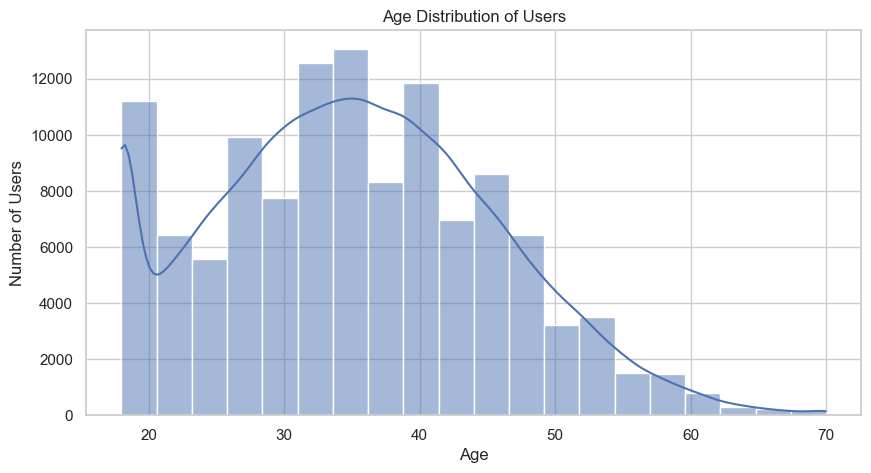

In [7]:
plt.figure(figsize=(10, 5))

sns.histplot(
    users["age"],
    bins=20,
    kde=True
)

plt.title("Age Distribution of Users")
plt.xlabel("Age")
plt.ylabel("Number of Users")

plt.show()

In [8]:
users["age"].describe()

count    120000.000000
mean         35.281675
std          10.402259
min          18.000000
25%          28.000000
50%          35.000000
75%          42.000000
max          70.000000
Name: age, dtype: float64

In [9]:
users[
    (users["age"] < 13) |
    (users["age"] > 100)
]

,user_id,signup_date,country,city,age,gender,customer_type,premium_member,signup_channel,lifetime_value,preferred_device


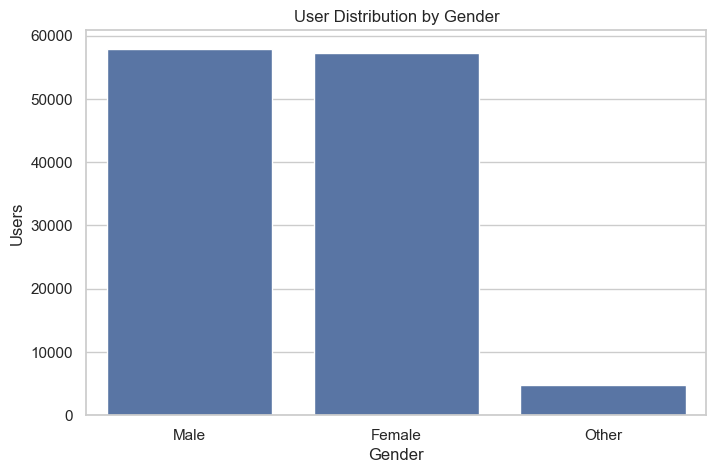

In [10]:
gender_counts = users["gender"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values
)

plt.title("User Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Users")

plt.show()

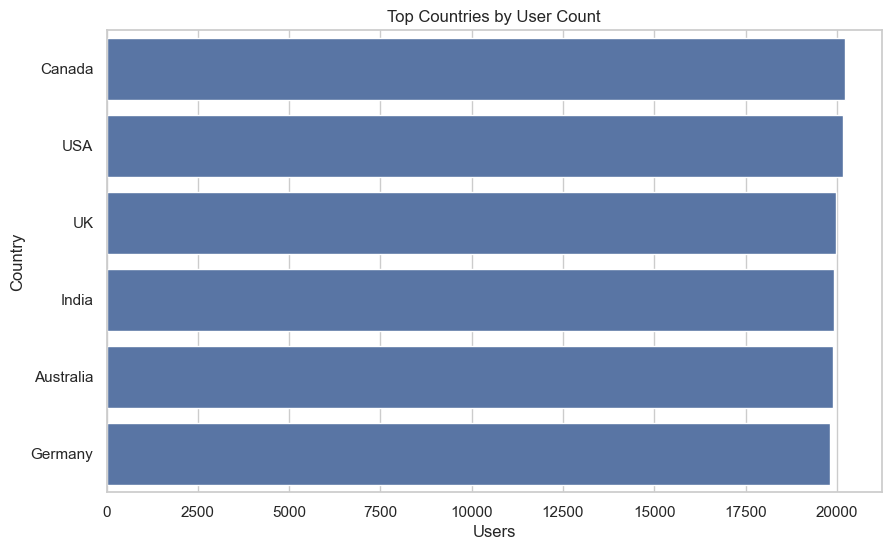

In [11]:
country_counts = users["country"].value_counts().head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

plt.title("Top Countries by User Count")
plt.xlabel("Users")
plt.ylabel("Country")

plt.show()

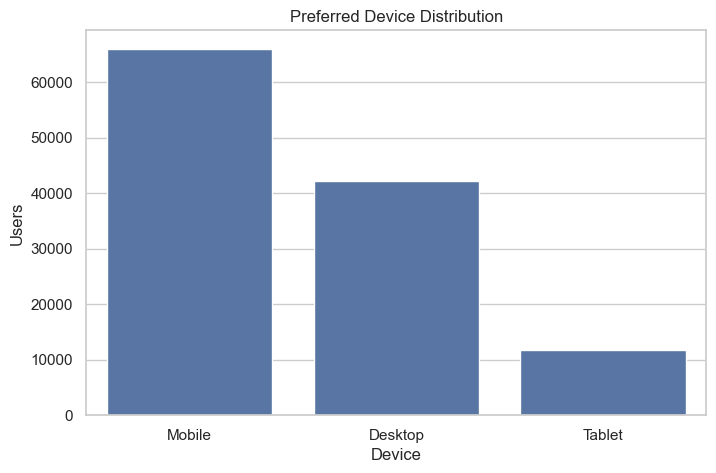

In [12]:
device_counts = users["preferred_device"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=device_counts.index,
    y=device_counts.values
)

plt.title("Preferred Device Distribution")
plt.xlabel("Device")
plt.ylabel("Users")

plt.show()

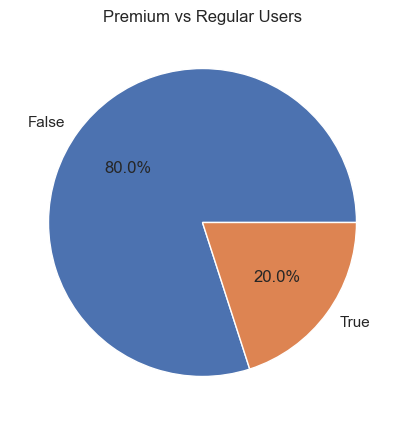

In [13]:
premium_counts = users["premium_member"].value_counts()

plt.figure(figsize=(7, 5))

plt.pie(
    premium_counts.values,
    labels=premium_counts.index,
    autopct="%1.1f%%"
)

plt.title("Premium vs Regular Users")

plt.show()

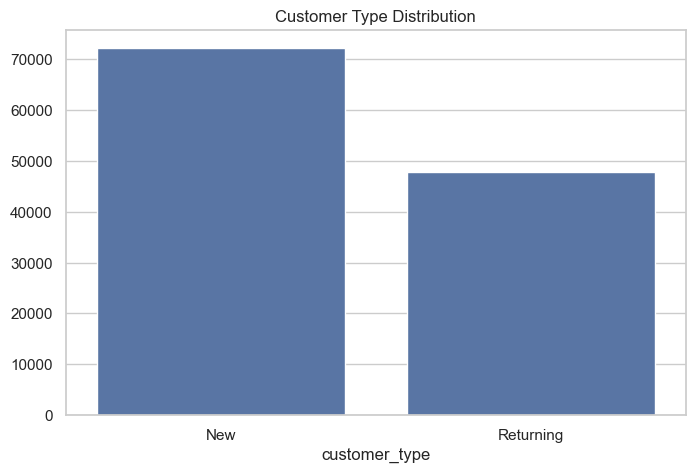

In [14]:
customer_counts = users["customer_type"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=customer_counts.index,
    y=customer_counts.values
)

plt.title("Customer Type Distribution")

plt.show()

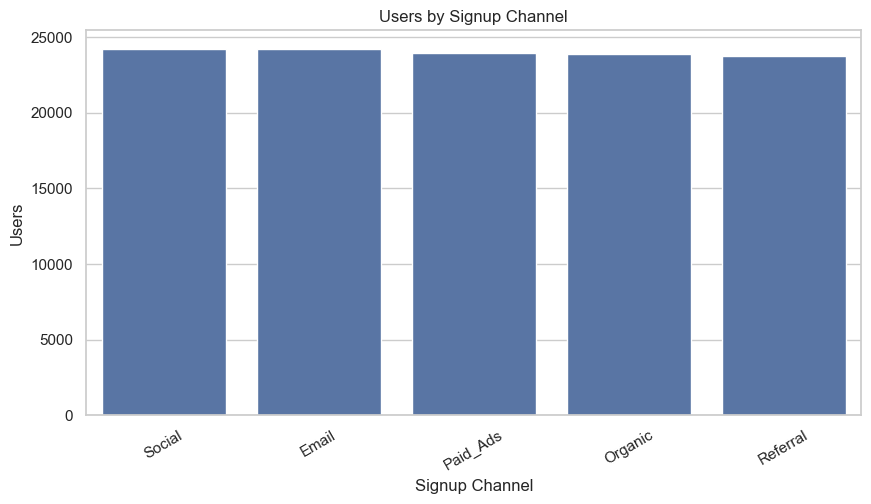

In [15]:
signup_counts = users["signup_channel"].value_counts()

plt.figure(figsize=(10, 5))

sns.barplot(
    x=signup_counts.index,
    y=signup_counts.values
)

plt.title("Users by Signup Channel")
plt.xlabel("Signup Channel")
plt.ylabel("Users")

plt.xticks(rotation=30)

plt.show()

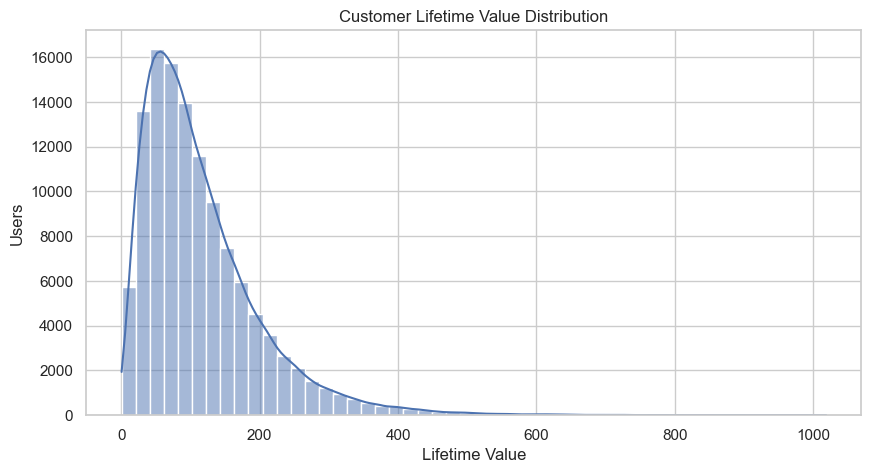

In [16]:
plt.figure(figsize=(10, 5))

sns.histplot(
    users["lifetime_value"],
    bins=50,
    kde=True
)

plt.title("Customer Lifetime Value Distribution")
plt.xlabel("Lifetime Value")
plt.ylabel("Users")

plt.show()

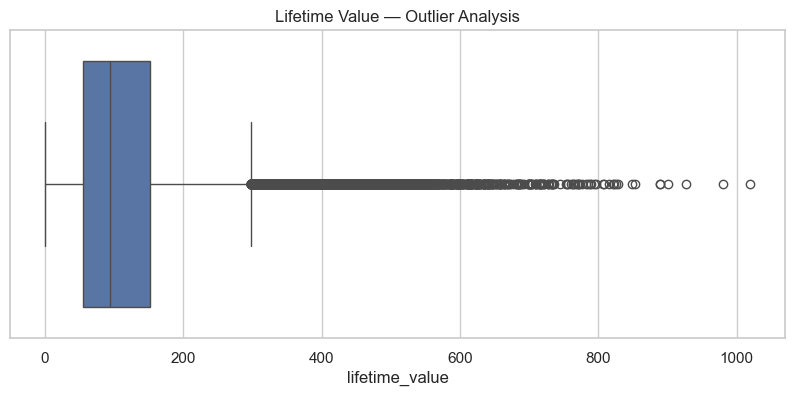

In [17]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=users["lifetime_value"]
)

plt.title("Lifetime Value — Outlier Analysis")

plt.show()

In [18]:
experiment["group"].value_counts()

group
Control      60000
Treatment    60000
Name: count, dtype: int64

In [19]:
experiment["group"].value_counts(normalize=True) * 100

group
Control      50.0
Treatment    50.0
Name: proportion, dtype: float64

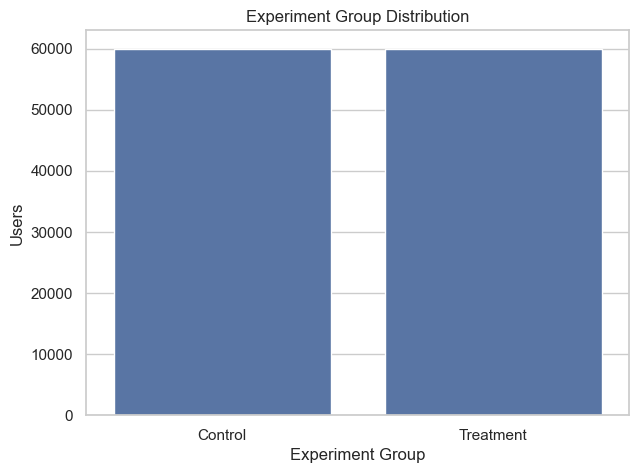

In [20]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=experiment,
    x="group"
)

plt.title("Experiment Group Distribution")
plt.xlabel("Experiment Group")
plt.ylabel("Users")

plt.show()

In [21]:
user_experiment = users.merge(
    experiment,
    on="user_id",
    how="inner"
)

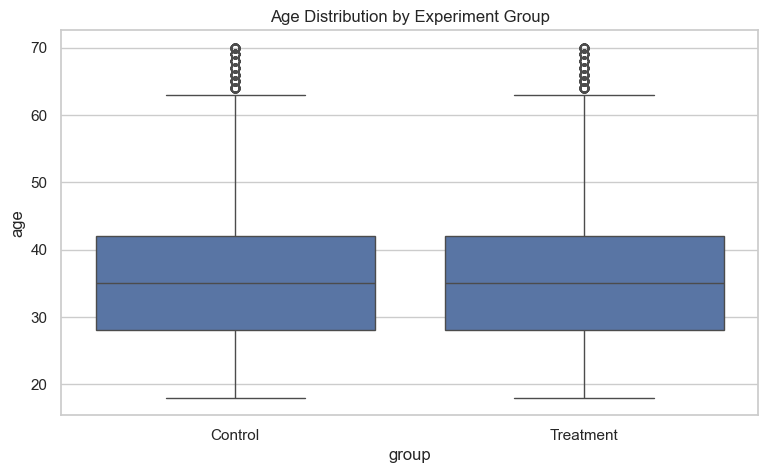

In [22]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=user_experiment,
    x="group",
    y="age"
)

plt.title("Age Distribution by Experiment Group")

plt.show()

In [23]:
user_experiment.groupby("group")["age"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
group,,,,
Control,60000,35.28260,35.0,10.426566
Treatment,60000,35.28075,35.0,10.377983


In [24]:
device_group = pd.crosstab(
    user_experiment["group"],
    user_experiment["preferred_device"],
    normalize="index"
) * 100

device_group

preferred_device,Desktop,Mobile,Tablet
group,,,
Control,35.366667,54.796667,9.836667
Treatment,34.940000,55.281667,9.778333


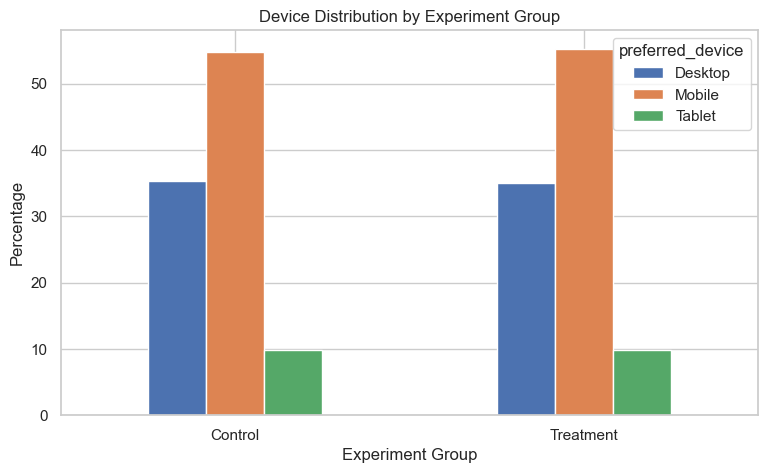

In [25]:
device_group.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Device Distribution by Experiment Group")
plt.ylabel("Percentage")
plt.xlabel("Experiment Group")

plt.xticks(rotation=0)

plt.show()

In [26]:
premium_group = pd.crosstab(
    user_experiment["group"],
    user_experiment["premium_member"],
    normalize="index"
) * 100

premium_group

premium_member,False,True
group,,
Control,80.000000,20.000000
Treatment,79.921667,20.078333


In [27]:
customer_group = pd.crosstab(
    user_experiment["group"],
    user_experiment["customer_type"],
    normalize="index"
) * 100

customer_group

customer_type,New,Returning
group,,
Control,60.126667,39.873333
Treatment,60.185000,39.815000


In [28]:
sessions["session_duration"].describe()

count    659860.000000
mean        231.593507
std         182.005034
min          30.000000
25%         113.140000
50%         181.460000
75%         290.980000
max        1800.000000
Name: session_duration, dtype: float64

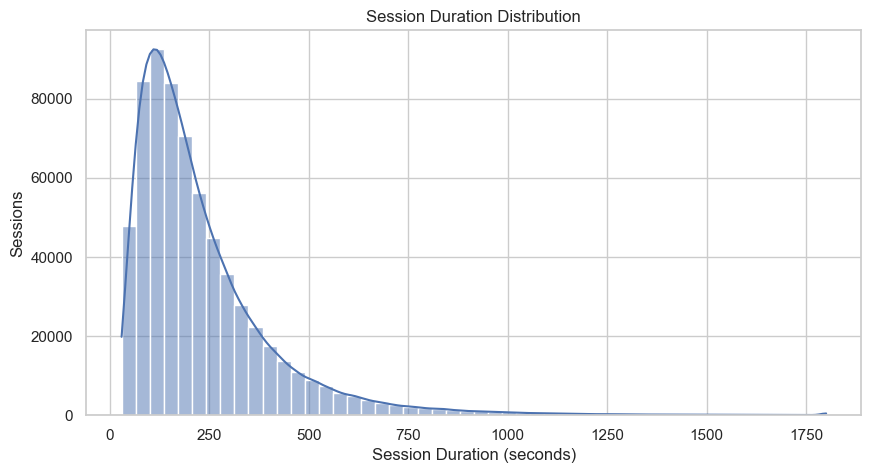

In [29]:
plt.figure(figsize=(10, 5))

sns.histplot(
    sessions["session_duration"],
    bins=50,
    kde=True
)

plt.title("Session Duration Distribution")
plt.xlabel("Session Duration (seconds)")
plt.ylabel("Sessions")

plt.show()

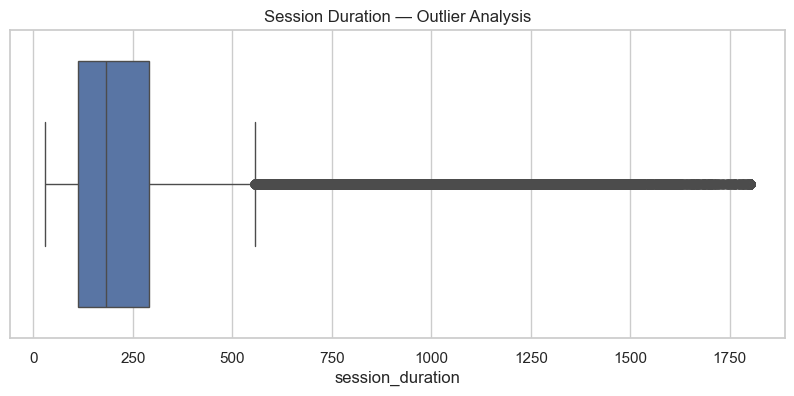

In [30]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=sessions["session_duration"]
)

plt.title("Session Duration — Outlier Analysis")

plt.show()

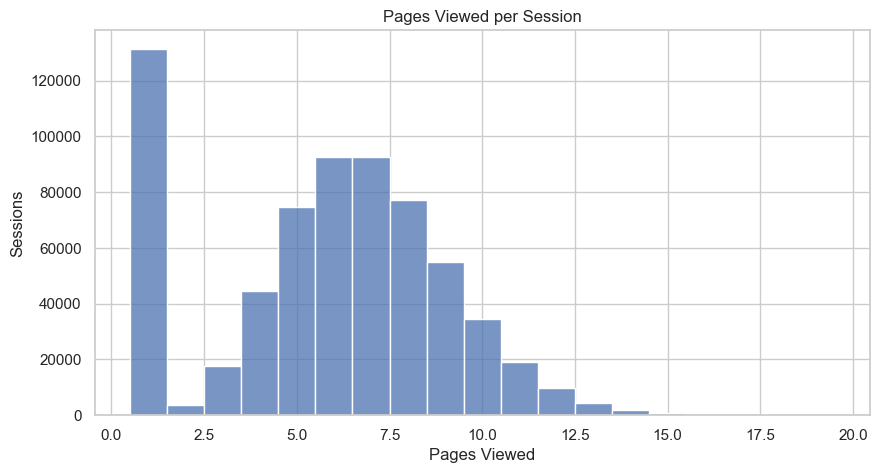

In [31]:
plt.figure(figsize=(10, 5))

sns.histplot(
    sessions["pages_viewed"],
    discrete=True
)

plt.title("Pages Viewed per Session")
plt.xlabel("Pages Viewed")
plt.ylabel("Sessions")

plt.show()

In [32]:
bounce_rate = sessions["bounce"].mean() * 100

print(f"Overall bounce rate: {bounce_rate:.2f}%")

Overall bounce rate: 19.93%


In [33]:
sessions.groupby("device")["bounce"].mean().mul(100).round(2)

device
Desktop    19.92
Mobile     19.93
Tablet     19.95
Name: bounce, dtype: float64

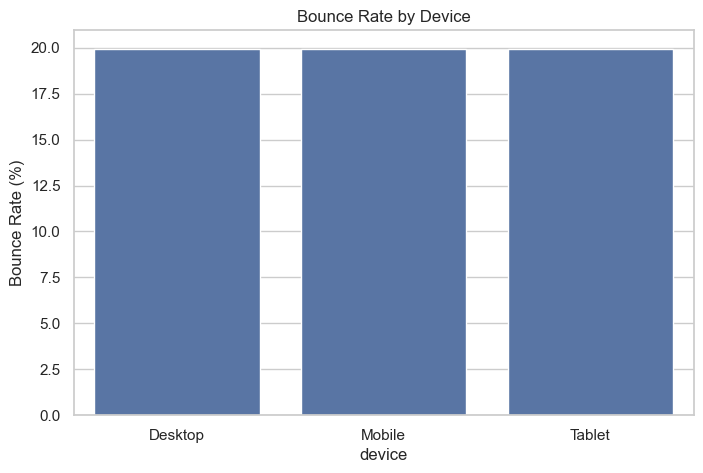

In [34]:
bounce_device = (
    sessions.groupby("device")["bounce"]
    .mean()
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=bounce_device,
    x="device",
    y="bounce"
)

plt.title("Bounce Rate by Device")
plt.ylabel("Bounce Rate (%)")

plt.show()

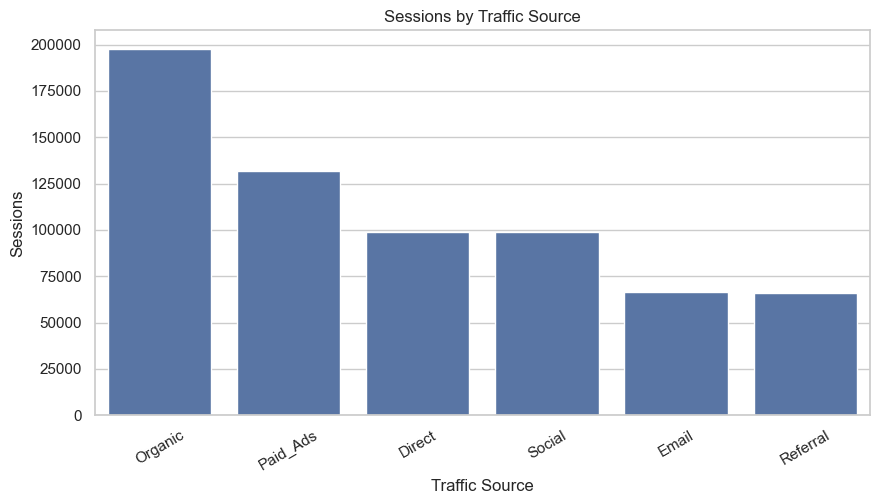

In [35]:
traffic_counts = sessions["traffic_source"].value_counts()

plt.figure(figsize=(10, 5))

sns.barplot(
    x=traffic_counts.index,
    y=traffic_counts.values
)

plt.title("Sessions by Traffic Source")
plt.xlabel("Traffic Source")
plt.ylabel("Sessions")

plt.xticks(rotation=30)

plt.show()

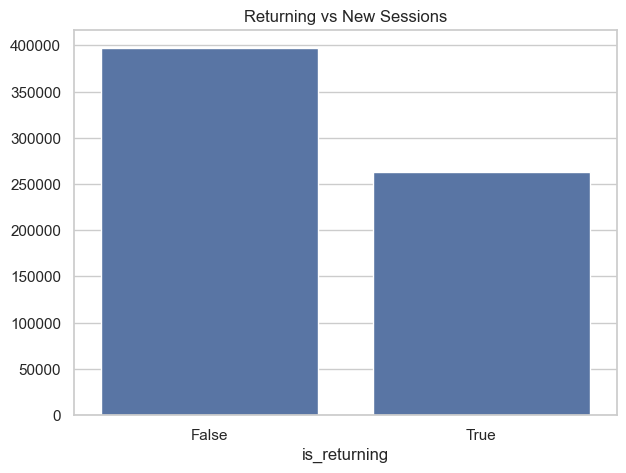

In [36]:
returning_counts = sessions["is_returning"].value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=returning_counts.index,
    y=returning_counts.values
)

plt.title("Returning vs New Sessions")

plt.show()

In [37]:
session_experiment = sessions.merge(
    experiment[["user_id", "group"]],
    on="user_id",
    how="left"
)

In [38]:
session_experiment.groupby("group")[
    "session_duration"
].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
group,,,,
Control,330509,231.835821,181.7,182.082884
Treatment,329351,231.350342,181.2,181.926829


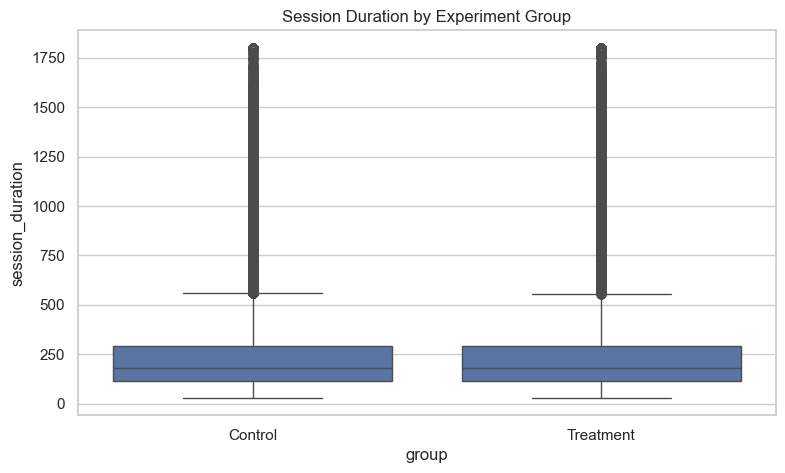

In [39]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=session_experiment,
    x="group",
    y="session_duration"
)

plt.title("Session Duration by Experiment Group")

plt.show()

In [40]:
events["event_name"].value_counts()

event_name
Homepage             659860
Search               448693
Product_View         314199
Category             179051
Add_To_Cart          109787
Checkout              76750
Shipping              72936
Purchase              44176
Payment               34720
One_Click_Payment     34580
Name: count, dtype: int64

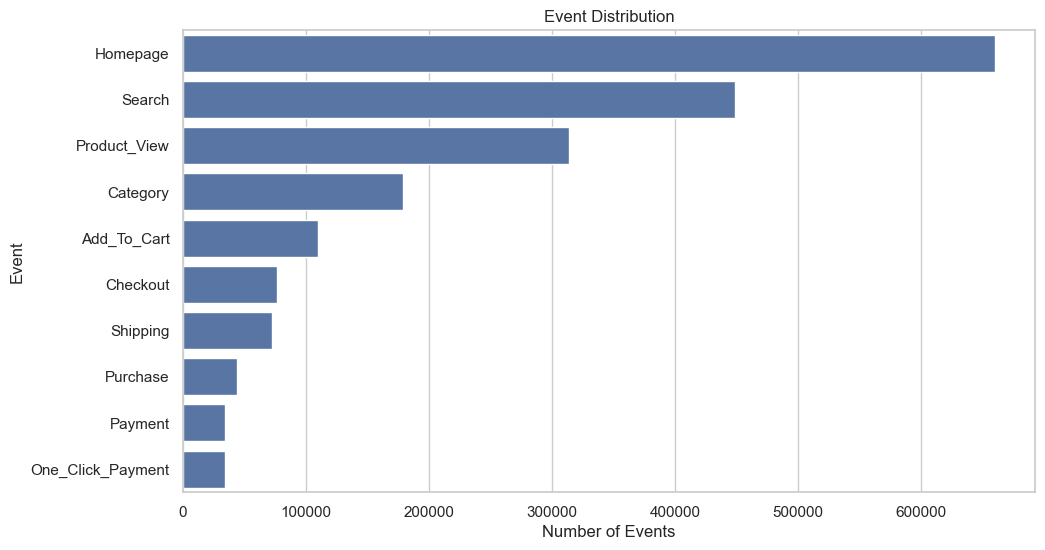

In [41]:
event_counts = events["event_name"].value_counts()

plt.figure(figsize=(11, 6))

sns.barplot(
    x=event_counts.values,
    y=event_counts.index
)

plt.title("Event Distribution")
plt.xlabel("Number of Events")
plt.ylabel("Event")

plt.show()

In [42]:
event_sequence = (
    events.groupby("event_sequence")
    .size()
    .reset_index(name="events")
)

event_sequence.head()

,event_sequence,events
0,1,659860
1,2,448693
2,3,367807
3,4,191436
4,5,90026


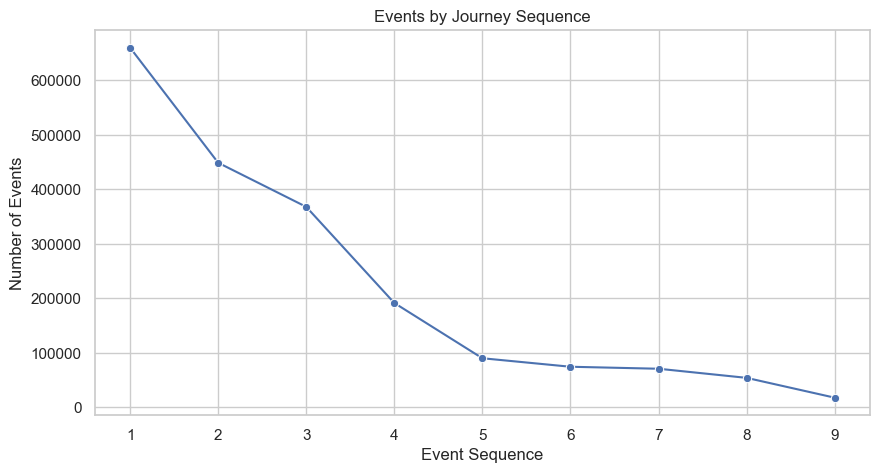

In [43]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=event_sequence,
    x="event_sequence",
    y="events",
    marker="o"
)

plt.title("Events by Journey Sequence")
plt.xlabel("Event Sequence")
plt.ylabel("Number of Events")

plt.show()

In [46]:
# event_experiment = (
#     events
#     .merge(
#         sessions[["session_id", "user_id"]],
#         on=["session_id", "user_id"],
#         how="left"
#     )
#     .merge(
#         experiment[["user_id", "group"]],
#         on="user_id",
#         how="left"
#     )
# )
event_experiment = (
    events
    .merge(
        sessions[["session_id", "user_id"]],
        on="session_id",
        how="left"
    )
    .merge(
        experiment[["user_id", "group"]],
        on="user_id",
        how="left"
    )
)

In [47]:
event_group_counts = pd.crosstab(
    event_experiment["event_name"],
    event_experiment["group"]
)

event_group_counts

group,Control,Treatment
event_name,,
Add_To_Cart,54972,54815
Category,89958,89093
Checkout,38476,38274
Homepage,330509,329351
One_Click_Payment,0,34580
Payment,34720,0
Product_View,157490,156709
Purchase,20903,23273
Search,224967,223726


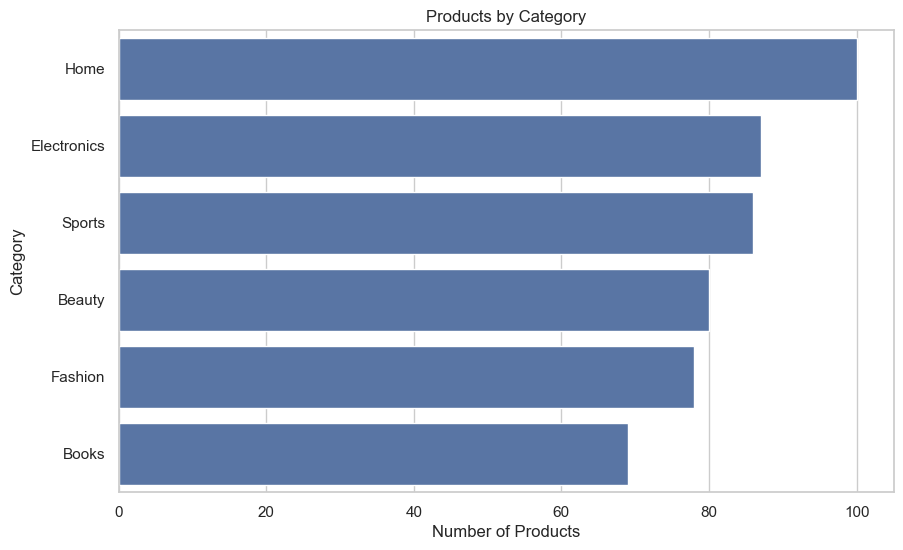

In [48]:
category_counts = products["category"].value_counts()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title("Products by Category")
plt.xlabel("Number of Products")
plt.ylabel("Category")

plt.show()

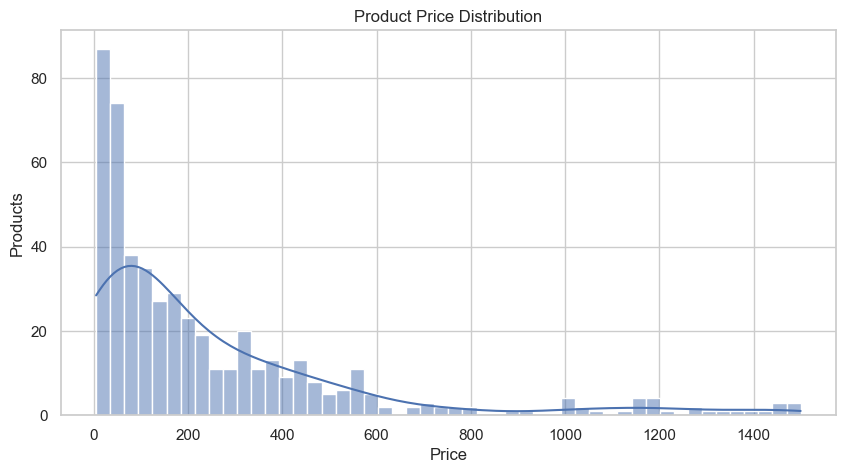

In [49]:
plt.figure(figsize=(10, 5))

sns.histplot(
    products["price"],
    bins=50,
    kde=True
)

plt.title("Product Price Distribution")
plt.xlabel("Price")
plt.ylabel("Products")

plt.show()

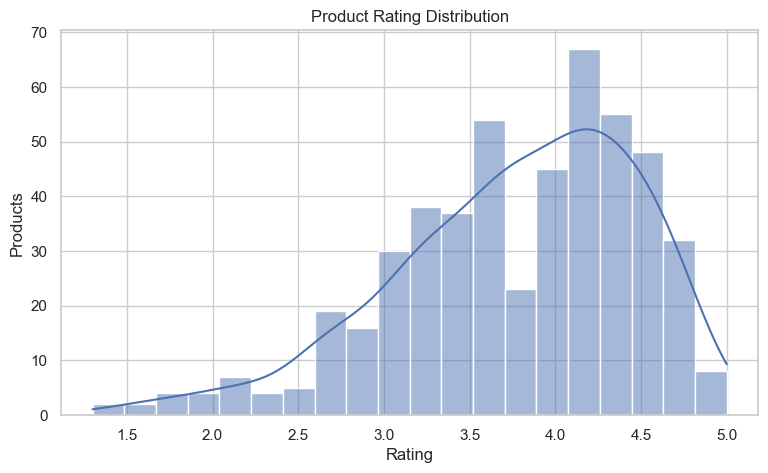

In [50]:
plt.figure(figsize=(9, 5))

sns.histplot(
    products["rating"],
    bins=20,
    kde=True
)

plt.title("Product Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Products")

plt.show()

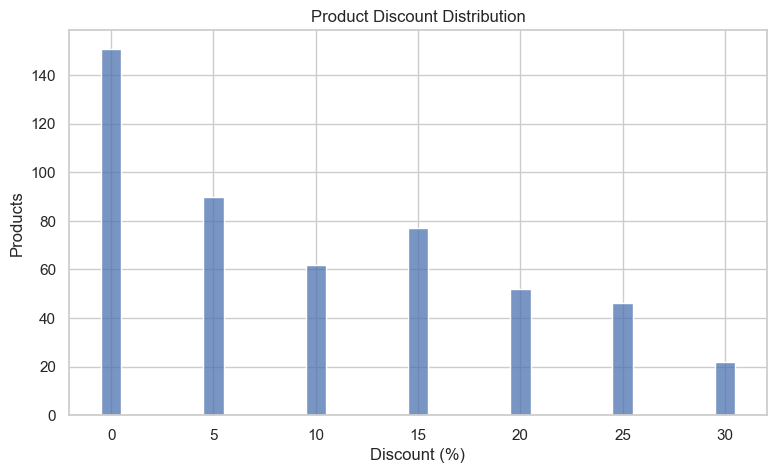

In [51]:
plt.figure(figsize=(9, 5))

sns.histplot(
    products["discount_percent"],
    discrete=True
)

plt.title("Product Discount Distribution")
plt.xlabel("Discount (%)")
plt.ylabel("Products")

plt.show()

In [52]:
orders.describe()

,quantity,unit_price,discount,shipping_cost,tax,total_amount,profit,purchase_time
count,44176.000000,44176.000000,44176.000000,44176.000000,44176.000000,44176.000000,44176.000000,44176
mean,2.385141,255.129986,69.509317,0.822372,43.186850,583.844329,156.833764,2026-04-01 03:48:21.742914816
min,1.000000,5.280000,0.000000,0.000000,0.320000,7.560000,-3266.480000,2026-01-01 00:16:18
25%,2.000000,51.210000,1.890000,0.000000,7.050000,95.210000,16.190000,2026-02-15 00:30:20.500000
50%,2.000000,144.170000,19.380000,0.000000,20.310000,274.230000,64.045000,2026-04-01 05:29:10.500000
75%,3.000000,337.360000,70.600000,0.000000,53.222500,718.475000,193.290000,2026-05-16 05:08:24.249999872
max,6.000000,1499.580000,2668.330000,8.000000,653.540000,8822.780000,4480.140000,2026-06-29 23:58:44
std,1.160228,308.029878,147.781512,2.036771,61.928521,835.494835,307.147962,NaN


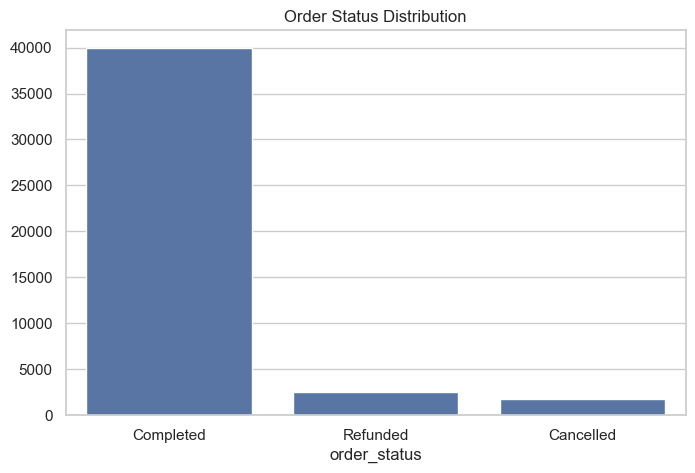

In [53]:
status_counts = orders["order_status"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=status_counts.index,
    y=status_counts.values
)

plt.title("Order Status Distribution")

plt.show()

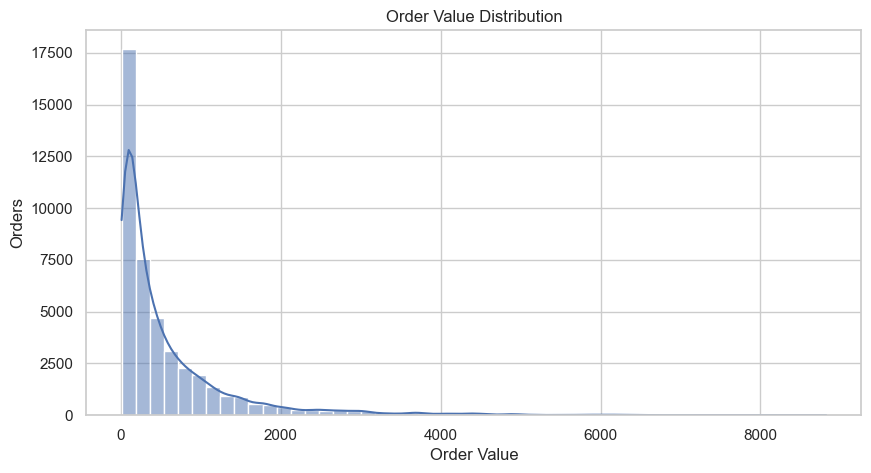

In [54]:
plt.figure(figsize=(10, 5))

sns.histplot(
    orders["total_amount"],
    bins=50,
    kde=True
)

plt.title("Order Value Distribution")
plt.xlabel("Order Value")
plt.ylabel("Orders")

plt.show()

In [55]:
completed_orders = orders[
    orders["order_status"] == "Completed"
]

aov = completed_orders["total_amount"].mean()

print(f"AOV: {aov:.2f}")

AOV: 584.58


In [56]:
revenue = completed_orders["total_amount"].sum()

print(f"Total Revenue: {revenue:,.2f}")

Total Revenue: 23,336,972.59


In [57]:
profit = completed_orders["profit"].sum()

print(f"Total Profit: {profit:,.2f}")

Total Profit: 7,047,577.50


In [58]:
profit_margin = (
    profit / revenue
) * 100

print(f"Profit Margin: {profit_margin:.2f}%")

Profit Margin: 30.20%


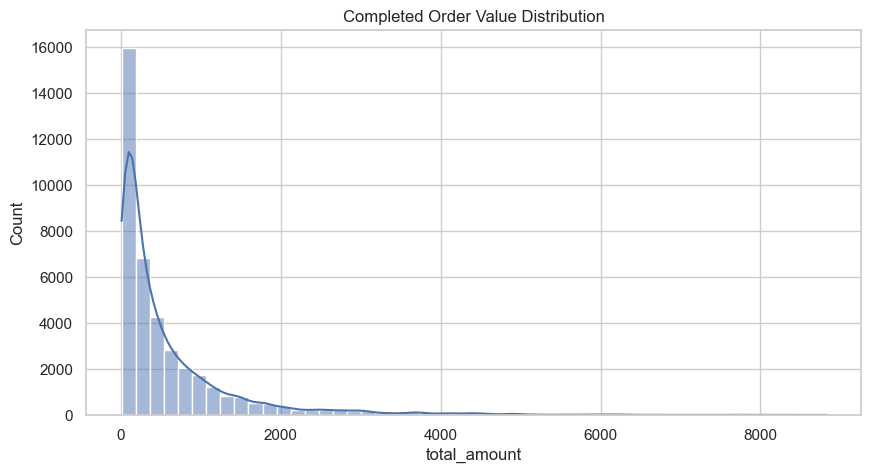

In [59]:
plt.figure(figsize=(10, 5))

sns.histplot(
    completed_orders["total_amount"],
    bins=50,
    kde=True
)

plt.title("Completed Order Value Distribution")

plt.show()

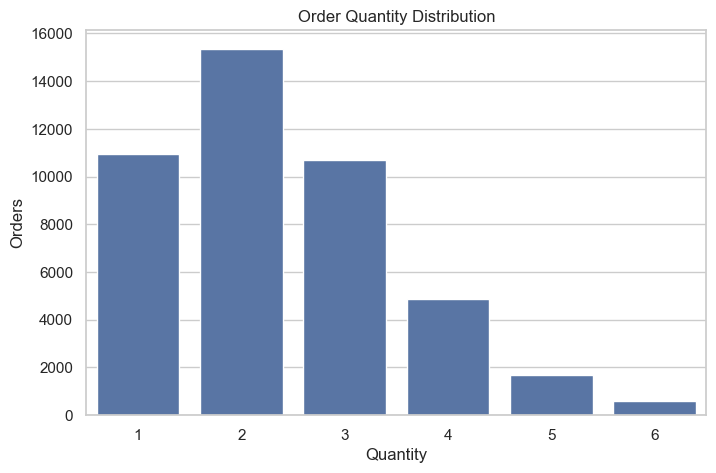

In [60]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=orders,
    x="quantity"
)

plt.title("Order Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Orders")

plt.show()

In [61]:
order_products = orders.merge(
    products[
        [
            "product_id",
            "category",
            "subcategory",
            "brand"
        ]
    ],
    on="product_id",
    how="left"
)

In [62]:
category_revenue = (
    order_products[
        order_products["order_status"] == "Completed"
    ]
    .groupby("category")["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

category
Electronics    11224636.86
Home            6027085.90
Sports          3056916.58
Fashion         1792673.01
Beauty           849471.70
Books            386188.54
Name: total_amount, dtype: float64

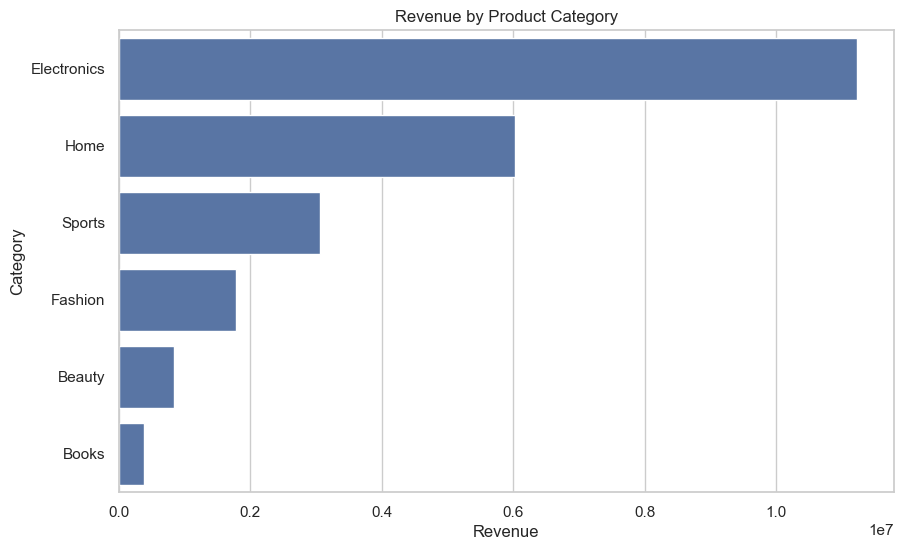

In [63]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_revenue.values,
    y=category_revenue.index
)

plt.title("Revenue by Product Category")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.show()

In [64]:
category_profit = (
    order_products[
        order_products["order_status"] == "Completed"
    ]
    .groupby("category")["profit"]
    .sum()
    .sort_values(ascending=False)
)

category_profit

category
Electronics    3426585.74
Home           1853237.21
Sports          888366.86
Fashion         517995.91
Beauty          252932.42
Books           108459.36
Name: profit, dtype: float64

In [65]:
refund_rate = (
    (orders["order_status"] == "Refunded").mean()
    * 100
)

print(f"Refund Rate: {refund_rate:.2f}%")

Refund Rate: 5.78%


In [66]:
refund_value = orders.loc[
    orders["order_status"] == "Refunded",
    "total_amount"
].sum()

print(f"Refunded Order Value: {refund_value:,.2f}")

Refunded Order Value: 1,441,621.20


In [67]:
orders_experiment = orders.merge(
    experiment[["user_id", "group"]],
    on="user_id",
    how="left"
)

In [68]:
revenue_by_group = (
    orders_experiment[
        orders_experiment["order_status"] == "Completed"
    ]
    .groupby("group")["total_amount"]
    .agg(["sum", "mean", "count"])
)

revenue_by_group

,sum,mean,count
group,,,
Control,11051289.95,585.902341,18862
Treatment,12285682.64,583.393449,21059


In [71]:
purchase_users = set(
    event_experiment.loc[
        event_experiment["event_name"] == "Purchase",
        "user_id"
    ].unique()
)

In [72]:
user_experiment = experiment.copy()

user_experiment["converted"] = (
    user_experiment["user_id"]
    .isin(purchase_users)
    .astype(int)
)

In [73]:
conversion_summary = (
    user_experiment
    .groupby("group")["converted"]
    .agg(
        users="count",
        conversions="sum",
        conversion_rate="mean"
    )
)

conversion_summary["conversion_rate"] *= 100

conversion_summary

,users,conversions,conversion_rate
group,,,
Control,60000,17493,29.155000
Treatment,60000,18928,31.546667


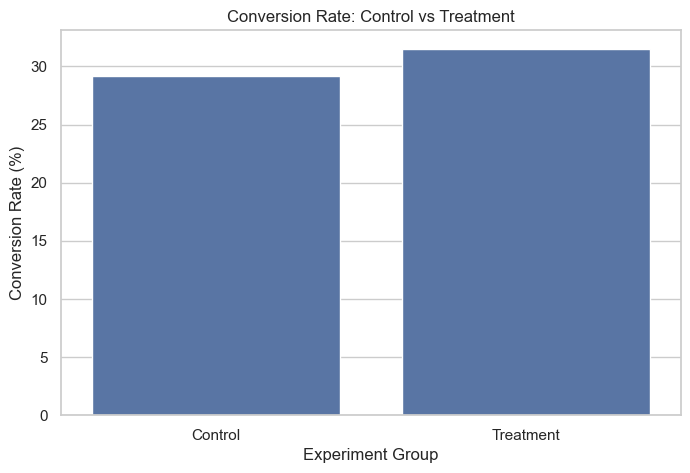

In [74]:
conversion_plot = (
    conversion_summary
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=conversion_plot,
    x="group",
    y="conversion_rate"
)

plt.title("Conversion Rate: Control vs Treatment")
plt.xlabel("Experiment Group")
plt.ylabel("Conversion Rate (%)")

plt.show()

In [75]:
analysis_df = (
    experiment[
        ["user_id", "group"]
    ]
    .merge(
        users,
        on="user_id",
        how="left"
    )
)

In [76]:
session_metrics = (
    sessions
    .groupby("user_id")
    .agg(
        total_sessions=("session_id", "nunique"),
        avg_session_duration=("session_duration", "mean"),
        total_pages_viewed=("pages_viewed", "sum"),
        avg_pages_viewed=("pages_viewed", "mean"),
        bounce_rate=("bounce", "mean")
    )
    .reset_index()
)

In [77]:
analysis_df = analysis_df.merge(
    session_metrics,
    on="user_id",
    how="left"
)

In [78]:
order_metrics = (
    orders[
        orders["order_status"] == "Completed"
    ]
    .groupby("user_id")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("total_amount", "sum"),
        profit=("profit", "sum"),
        avg_order_value=("total_amount", "mean")
    )
    .reset_index()
)

In [79]:
analysis_df = analysis_df.merge(
    order_metrics,
    on="user_id",
    how="left"
)

In [80]:
analysis_df[
    ["orders", "revenue", "profit", "avg_order_value"]
] = analysis_df[
    ["orders", "revenue", "profit", "avg_order_value"]
].fillna(0)

In [81]:
analysis_df["converted"] = (
    analysis_df["orders"] > 0
).astype(int)

In [82]:
analysis_df.head()

,user_id,group,signup_date,country,city,age,gender,customer_type,premium_member,signup_channel,...,total_sessions,avg_session_duration,total_pages_viewed,avg_pages_viewed,bounce_rate,orders,revenue,profit,avg_order_value,converted
0,USR_000001,Control,2025-08-23,India,Hyderabad,32,Male,New,False,Paid_Ads,...,1,624.36,1,1.000,1.0,0.0,0.00,0.00,0.00,0
1,USR_000002,Treatment,2024-07-01,Germany,Munich,40,Male,New,False,Social,...,8,175.27,63,7.875,0.0,1.0,147.17,42.21,147.17,1
2,USR_000003,Treatment,2025-12-06,India,Bangalore,52,Male,New,False,Social,...,6,280.23,33,5.500,0.0,0.0,0.00,0.00,0.00,0
3,USR_000004,Treatment,2025-05-19,Canada,Ottawa,25,Female,Returning,False,Social,...,2,292.88,2,1.000,1.0,0.0,0.00,0.00,0.00,0
4,USR_000005,Treatment,2023-04-28,India,Mumbai,41,Male,New,False,Organic,...,1,209.77,8,8.000,0.0,0.0,0.00,0.00,0.00,0


In [83]:
analysis_df.shape

(120000, 22)

In [84]:
analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   user_id               120000 non-null  object        
 1   group                 120000 non-null  object        
 2   signup_date           120000 non-null  datetime64[ns]
 3   country               120000 non-null  object        
 4   city                  120000 non-null  object        
 5   age                   120000 non-null  int64         
 6   gender                120000 non-null  object        
 7   customer_type         120000 non-null  object        
 8   premium_member        120000 non-null  bool          
 9   signup_channel        120000 non-null  object        
 10  lifetime_value        120000 non-null  float64       
 11  preferred_device      120000 non-null  object        
 12  total_sessions        120000 non-null  int64         
 13 

In [85]:
analysis_df.groupby("group").agg(
    users=("user_id", "count"),
    conversion_rate=("converted", "mean"),
    revenue=("revenue", "sum"),
    profit=("profit", "sum"),
    avg_order_value=("avg_order_value", "mean")
)

,users,conversion_rate,revenue,profit,avg_order_value
group,,,,,
Control,60000,0.267317,11051289.95,3338739.33,156.503551
Treatment,60000,0.291283,12285682.64,3708838.17,170.280673


In [86]:
analysis_df.to_csv(
    "../data/processed/user_level_analysis.csv",
    index=False
)